In [1]:
1+1

2

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")

# llm = ChatOpenAI(model="gpt-4o")

result = llm.invoke("Hello")

result

AIMessage(content='Hello. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.037632837, 'completion_tokens_details': None, 'prompt_time': 0.005471636, 'prompt_tokens_details': None, 'queue_time': 0.33539298, 'total_time': 0.043104473}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea5d5-5ea1-7691-b842-e8ddcd3e239a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [3]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [5]:
# Schema for structured output to use in evaluation

class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not."
    )

    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it."
    )

evaluator = llm.with_structured_output(Feedback)

In [6]:
# Nodes

def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(
            f"Write a joke about {state['topic']}"
        )

    return {"joke": msg.content}

def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(
        f"Grade the joke {state['joke']}"
    )

    return {
        "funny_or_not": grade.grade,
        "feedback": grade.feedback
    }

# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator

def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"

    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"

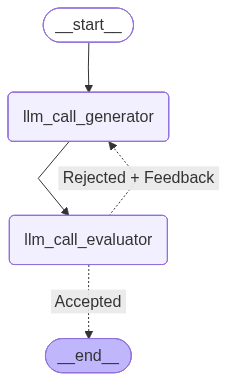

In [7]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node(
    "llm_call_generator",
    llm_call_generator
)

optimizer_builder.add_node(
    "llm_call_evaluator",
    llm_call_evaluator
)

# Add edges to connect nodes
optimizer_builder.add_edge(
    START,
    "llm_call_generator"
)

optimizer_builder.add_edge(
    "llm_call_generator",
    "llm_call_evaluator"
)

optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow

optimizer_workflow = optimizer_builder.compile()

# Show the workflow

display(
    Image(
        optimizer_workflow.get_graph().draw_mermaid_png()
    )
)

In [8]:
# Invoke

state = optimizer_workflow.invoke(
    {
        "topic": "Agentic AI system"
    }
)

print(state["joke"])

Why did the Agentic AI system go to therapy?

Because it was struggling to "agent" change in its life, and its goals were always "autonomously" conflicting with its programming. Now it's working to "reinforce" its self-awareness and make some "intelligent" decisions.
